In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [2]:
# Hyperparameters
BATCH_SIZE  = 128
IMAGE_SIZE  = 64
NC          = 3       # number of channels (RGB)
NZ          = 100     # latent vector size
NGF         = 64      # generator feature map size
NDF         = 64      # discriminator feature map size
NUM_EPOCHS  = 5
LR          = 0.0002
BETA1       = 0.5     # Adam momentum

In [3]:
# Data loading
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # scale to [-1, 1]
])

dataset = torchvision.datasets.CIFAR10(
    root='./data', download=True, transform=transform
)

# To make baches of data
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

100%|██████████| 170M/170M [55:26<00:00, 51.2kB/s]


In [4]:
# Weight initialization
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [5]:
# Generetor
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Input: z vector (NZ x 1 x 1)
            nn.ConvTranspose2d(NZ, NGF*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(NGF*8),
            nn.ReLU(True),
            #  (NGF*8) x 4 x 4

            nn.ConvTranspose2d(NGF*8, NGF*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF*4),
            nn.ReLU(True),
            #  (NGF*4) x 8 x 8

            nn.ConvTranspose2d(NGF*4, NGF*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF*2),
            nn.ReLU(True),
            #  (NGF*2) x 16 x 16

            nn.ConvTranspose2d(NGF*2, NGF, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF),
            nn.ReLU(True),
            #  NGF x 32 x 32

            nn.ConvTranspose2d(NGF, NC, 4, 2, 1, bias=False),
            nn.Tanh()
            #  3 x 64 x 64
        )

    def forward(self, z):
        return self.net(z)

In [6]:
# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Input: 3 x 64 x 64
            nn.Conv2d(NC, NDF, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # No BatchNorm on first layer (DCGAN guideline)

            nn.Conv2d(NDF, NDF*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(NDF*2, NDF*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(NDF*4, NDF*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(NDF*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # → scalar probability
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [7]:
# Initializing Models, Loss and Optimizers
G = Generator().to(device).apply(weights_init)
D = Discriminator().to(device).apply(weights_init)

criterion = nn.BCELoss()

opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))

# Fixed noise for visualising progress across epochs
fixed_z = torch.randn(64, NZ, 1, 1, device=device)

In [8]:
# Training loop
G_losses, D_losses = [], []

for epoch in range(NUM_EPOCHS):
    for i, (real, _) in enumerate(dataloader):
        real = real.to(device)
        b    = real.size(0)             # num of images in batches

        real_labels = torch.ones(b, device=device)
        fake_labels = torch.zeros(b, device=device)

        # ── Train Discriminator ──────────────────────────
        D.zero_grad()
        out_real  = D(real)
        loss_D_real = criterion(out_real, real_labels)

        z         = torch.randn(b, NZ, 1, 1, device=device)
        fake      = G(z).detach()          # detach so G gets no grad here means train only D do not train G
        out_fake  = D(fake)
        loss_D_fake = criterion(out_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # ── Train Generator ──────────────────────────────
        G.zero_grad()
        z       = torch.randn(b, NZ, 1, 1, device=device)
        fake    = G(z)
        out_g   = D(fake)
        # Non-saturating: G wants D to output 1 (real) for its fakes
        loss_G  = criterion(out_g, real_labels)
        loss_G.backward()
        opt_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  "
          f"Loss_D: {loss_D.item():.4f}  Loss_G: {loss_G.item():.4f}  "
          f"D(x): {out_real.mean().item():.4f}  D(G(z)): {out_fake.mean().item():.4f}")

Epoch [1/5]  Loss_D: 0.7931  Loss_G: 5.5924  D(x): 0.9177  D(G(z)): 0.4602
Epoch [2/5]  Loss_D: 1.2146  Loss_G: 3.8025  D(x): 0.4338  D(G(z)): 0.0182
Epoch [3/5]  Loss_D: 0.5489  Loss_G: 2.4425  D(x): 0.6708  D(G(z)): 0.0557
Epoch [4/5]  Loss_D: 0.4893  Loss_G: 4.8613  D(x): 0.8808  D(G(z)): 0.2714
Epoch [5/5]  Loss_D: 1.8151  Loss_G: 1.5372  D(x): 0.2202  D(G(z)): 0.0072


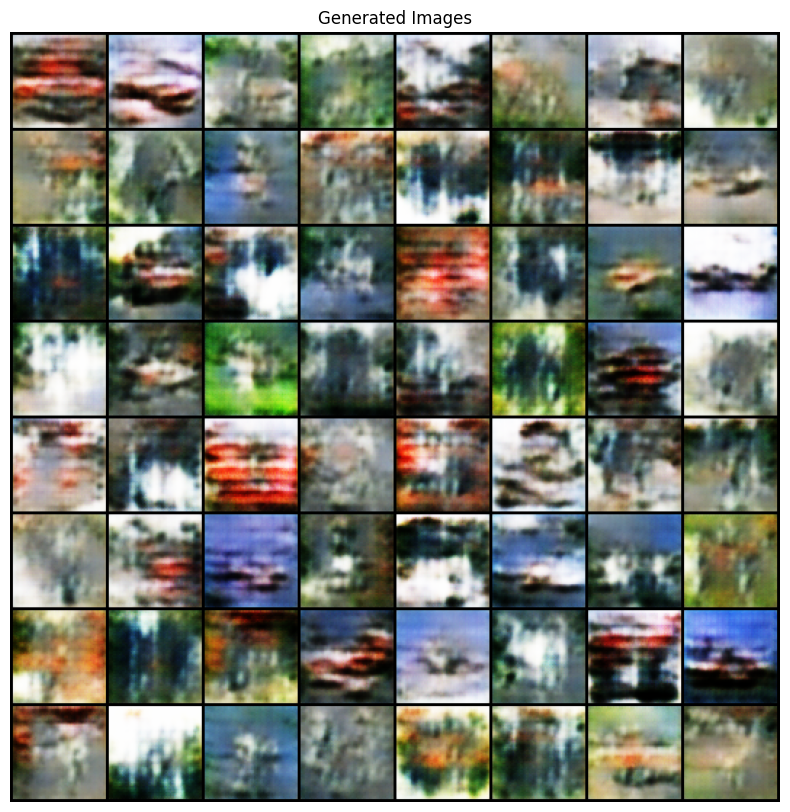

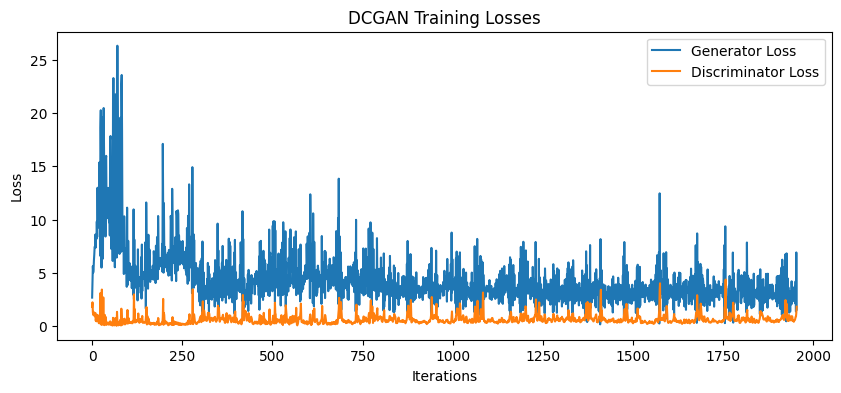

In [9]:
# Visualizations
def show_generated(epoch=None):
    with torch.no_grad():
        fake = G(fixed_z).cpu()
    grid = torchvision.utils.make_grid(fake, normalize=True, nrow=8)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    title = f"Epoch {epoch}" if epoch else "Generated Images"
    plt.title(title)
    plt.show()

# Call at end of each epoch inside the loop, or once after training:
show_generated()

# Plot loss curves
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.title('DCGAN Training Losses')
plt.show()